In [1]:
from sys import path

path.append("..")

import os
from pathlib import Path

os.chdir(Path.cwd().parent)

In [2]:
from comparison import tests
import pandas as pd
import numpy as np

In [3]:
import psutil

psutil.cpu_count()

12

In [10]:
from joblib import Parallel, delayed
args = [{'arg' : i} for i in range(10)]
Parallel(n_jobs=psutil.cpu_count())(delayed(lambda x: x['arg'])(kwargs) for kwargs in args)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

## CHECK for desrciptors 
(edge and node should return the vector with the size respectfully proportionall to edges and nodes)

In [11]:
from graph_utils.reading import read_graph6
from descriptors.edge_descriptors import edge_descriptors_dict
from descriptors.node_descriptors import node_descriptors_dict


gr = read_graph6('graph7c')
for _ in range(200):
    g = next(gr)

for k, f in edge_descriptors_dict.items():
    print(k, f(g).shape)
print()
print()
print()

for k, f in node_descriptors_dict.items():
    print(k, f(g).shape)

jaccard_index (12,)
jaccard_index_normalized (12,)
adamic_adar (12,)
katz_index (12,)
neighborhood_distance (12,)
neighborhood_measure (12,)
preferential_attachment (12,)
resource_allocation (12,)
same_community (12,)
total_nieghbors (12,)
algebraic_distance (12,)
ari (12,)
lds (12,)
scan (12,)
cn_quadrangle (12,)
cn_triangle (12,)
lss (12,)
simmelian_sparsifier_np (12,)
edge_betweenness (12,)
edge_betweenness_normalized (12,)
spanning_edge (12,)



ldp_degree (7,)
ldp_min (7,)
ldp_min_normalized (7,)
ldp_max (7,)
ldp_max_normalized (7,)
ldp_mean (7,)
ldp_mean_normalized (7,)
ldp_std (7,)
ldp_std_normalized (7,)
eigenvector_centrality (7,)
closeness (7,)
closeness_normalized (7,)
degree_centrality (7,)
degree_centrality_normalized (7,)
katz_centrality (7,)
lcc (7,)


In [19]:
arguments_list = []

for dataset_name in ['graph9c']:
    # for features in [("moltop",), ("moltop","ltp"), ("moltop", "ldp"), ("moltop", "ltp", "ldp")]:
    for features in [(k, ) for k in edge_descriptors_dict.keys()] + [(k, ) for k in node_descriptors_dict.keys()]:
    
        features = np.array(features)
        arguments_list.append(dict(dataset_name=dataset_name,
                                    features=features,))

In [20]:
tests(arguments_list)

  0%|          | 0/37 [00:00<?, ?it/s]

  0%|          | 0/261079 [00:00<?, ?it/s, histogram_ranges]

  0%|          | 0/37 [00:00<?, ?it/s]

In [21]:
import json
from graph_utils.reading import read_metadata

metadata = read_metadata()

In [22]:
test_data = pd.read_parquet('processed_datasets/table.parquet')
test_data['count'] = test_data['result'].apply(len)

test_data['percentage'] = test_data.apply(lambda x: x['count'] / metadata[x['dataset_name']]['graph_count'], axis=1)

In [23]:
test_data

,features,dataset_name,result,count,percentage
0,[jaccard_index],graph7c,"[0, 1, 3, 4, 8, 20, 23, 25, 46, 215, 224, 2, 5...",700,0.820633
1,[jaccard_index_normalized],graph7c,"[0, 1, 3, 4, 8, 20, 23, 25, 46, 215, 224, 6, 1...",183,0.214537
2,[adamic_adar],graph7c,"[0, 1, 3, 4, 8, 20, 23, 25, 46, 215, 224, 6, 1...",237,0.277843
3,[katz_index],graph7c,"[0, 1, 3, 4, 8, 20, 23, 25, 46, 215, 224, 2, 5...",700,0.820633
4,[neighborhood_distance],graph7c,"[0, 1, 3, 4, 8, 20, 23, 25, 46, 215, 224, 6, 1...",177,0.207503
...,...,...,...,...,...
8,[closeness_normalized],graph9c,"[27, 163, 33, 192, 179, 273, 6771, 31, 289, 18...",250150,0.958135
9,[degree_centrality],graph9c,"[4, 35, 6, 36, 9, 38, 91, 11, 39, 41, 86, 93, ...",260531,0.997897
10,[degree_centrality_normalized],graph9c,"[4, 35, 6, 36, 9, 38, 91, 11, 39, 41, 86, 93, ...",260531,0.997897
11,[katz_centrality],graph9c,"[973, 1134, 22211, 1266, 1438, 1267, 1439, 133...",96475,0.369523


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
test_data['features'] = test_data['features'].astype('string').astype('category')
test_data.columns

Index(['features', 'dataset_name', 'result', 'count', 'percentage'], dtype='object')

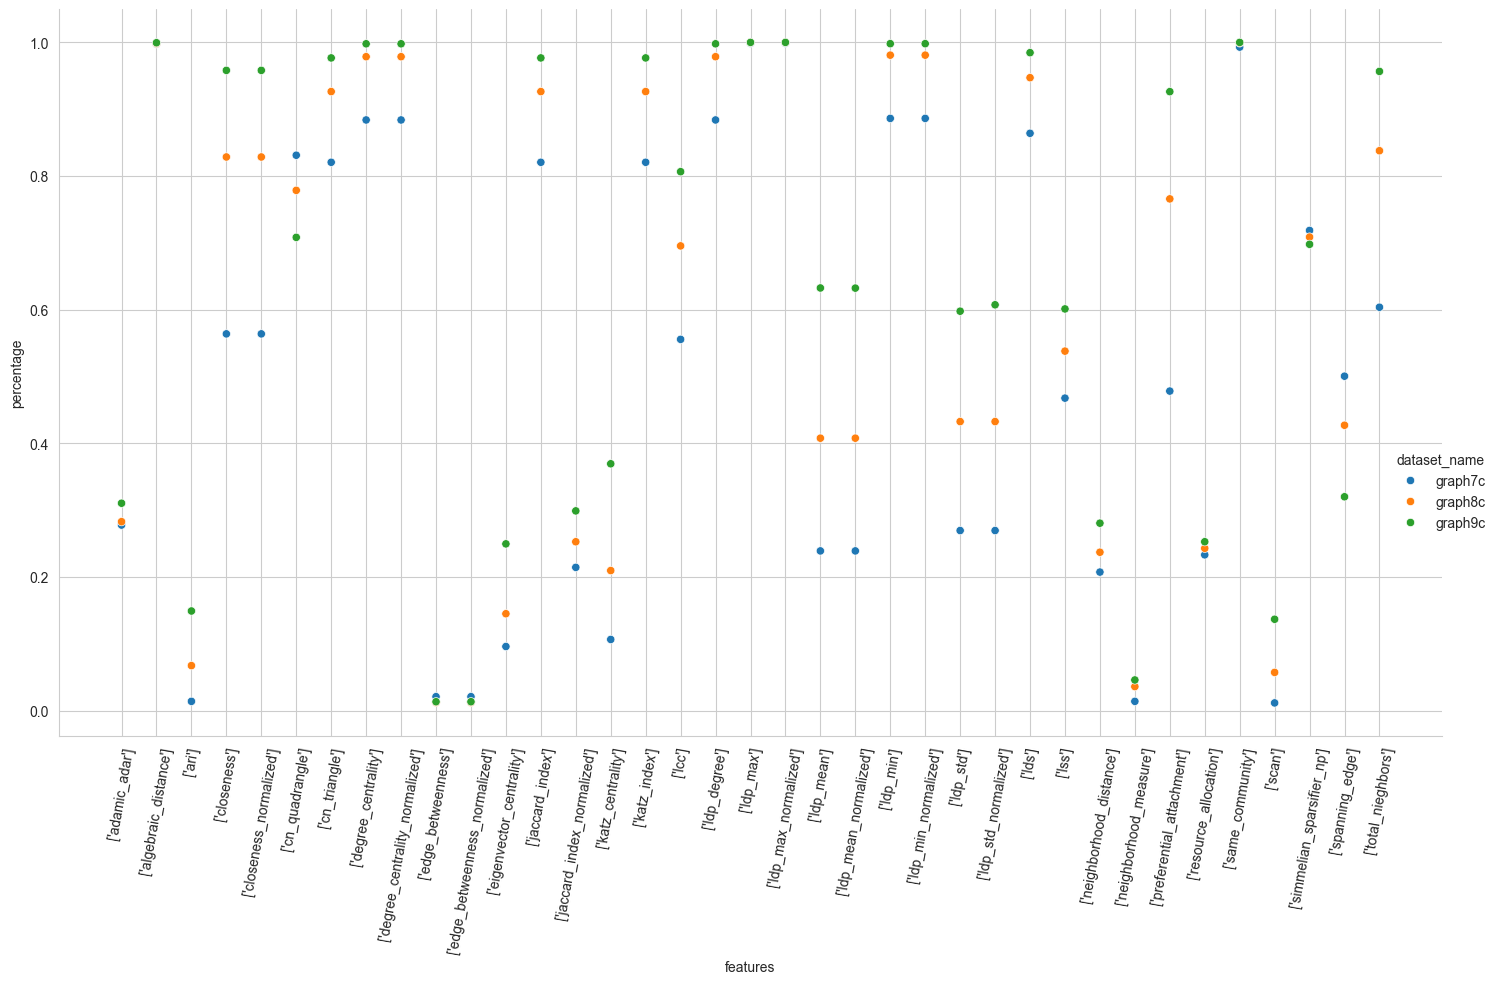

In [25]:
g = sns.pairplot(test_data.drop(columns=['result']), 
             y_vars=['percentage'],
             x_vars=['features'],
             hue='dataset_name',
             )
fig = plt.gcf()
fig.set_size_inches(15,8)
plt.tight_layout()

for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(80)

